# Telemetry causal inference

This notebook:

1. Loads `data/telemetry 1.jsonl` (robotic-arm object-detection pipeline telemetry, 6 scenario types) and engineers a flat metrics table.
2. Fits the causal graph + Bayesian Network from `causality/causal_discovery.py` and `causality/causal_inference.py` to that table.
3. Builds a general `diagnose(evidence)` function: given any subset of the graph's nodes (however much telemetry happens to be available), rank every other node by the probability it's the cause of the observed evidence — and evaluates it on an 80/20 held-out split against the simulator's ground-truth fault labels.
4. Shows how to stand up the same analyzer as an HTTP server via `causality/causal_inference_server.py`, so other processes can query it without refitting.

All 11 metrics (`frame_rate`, `arrival_rate_resizer`, `arrival_rate_detector`, `frame_resolution`, `cpu_usage_resizer`, `cpu_usage_detector`, `connection`, `completion_rate_resizer`, `completion_rate_detector`, `latency_resizer`, `latency_detector`) are *observed* telemetry, not decisions the scheduler controls — so none of them are `NodeType.INPUT` (that type is reserved for controllable decision variables elsewhere in this repo, e.g. thread counts). Here every node is `intermediary` except `latency_detector`, which is the `kpi` (it's the end-to-end pipeline latency the arm ultimately experiences; `latency_resizer` is only the resize-stage's own latency reading).

In [43]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "causality" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import json
import re

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

from causality.causal_discovery import infer_causal_graph_correlation
from causality.causal_inference import CausalAnalyzer
from environment import NodeType

pd.set_option("display.width", 120)

## 1. Load `telemetry 1.jsonl` and engineer features

`data/telemetry 1.jsonl` (1373 records) is the richer of the two telemetry dumps in `data/` — it's the only one that includes the `cpu_stress` / `cpu_stress_intermittent` scenarios, so it's what we use here instead of the smaller `data/telemetry.jsonl` (640 records, only 4 scenario types). Each JSON line is one snapshot of the `frame-sampler → frame-resizer → object-detector → robotic arm` pipeline.

`frame-resizer` and `object-detector` each report their own `frame_arrival`, `cpu`, and `latency_ms`, and each service's logs carry enough detail to compute a stage-local completion rate — so `arrival_rate`, `cpu_usage`, `completion_rate`, and `latency` are each split into a `_resizer` and a `_detector` column instead of collapsing to one number per metric. That gives 11 columns total:

| column | source | meaning |
|---|---|---|
| `frame_rate` | `frame-sampler.metrics.frame_sent` | frames/sec leaving the camera-side sampler |
| `arrival_rate_resizer` | `frame-resizer.metrics.frame_arrival` | frames/sec arriving at the resizer |
| `arrival_rate_detector` | `object-detector.metrics.frame_arrival` | frames/sec arriving at the detector |
| `frame_resolution` | parsed from `frame-resizer` logs (`"... Target WxH ..."`) | mean resized frame area (px²) |
| `cpu_usage_resizer` | `frame-resizer.metrics.cpu` | resizer CPU share |
| `cpu_usage_detector` | `object-detector.metrics.cpu` | detector CPU share |
| `connection` | `object-detector.metrics.arm_request_duration_ms` | round-trip time of arm requests (proxy for arm reachability) |
| `completion_rate_resizer` | `frame-resizer` logs: `"Sent frame to object-detector"` / `"Received frame from frame-sampler"` | fraction of frames that made it through the resize stage without timing out |
| `completion_rate_detector` | `object-detector` logs: `"Total frame processing time"` / `"Received frame from frame-resizer"` | fraction of frames the detector finished processing after receiving them |
| `latency_resizer` | `frame-resizer.metrics.latency_ms` | resize-stage latency |
| `latency_detector` | `object-detector.metrics.latency_ms` | end-to-end pipeline latency (the KPI) |

**Why the resizer/detector CPU columns tell different stories:** under CPU stress, `cpu_usage_detector` barely moves (≈3.5–3.8 across every label) — the stress isn't injected there. `cpu_usage_resizer` collapses from ≈0.12 (`normal`) to ≈0.007 (`cpu_stress`) and ≈0.07 (`cpu_stress_intermittent`) — the same starvation pattern `frame-sampler.metrics.cpu` shows (≈0.32 → ≈0.01 → ≈0.20), consistent with the sampler and resizer sharing whatever resource the stress generator is starving. We read the resizer's own `cpu` field for `cpu_usage_resizer` (rather than substituting `frame-sampler.cpu` under a resizer-labeled column), so the graph reflects only what each of the two named services reports about itself.

The dataset carries a `label` column (`normal`, `arm_unreachable`, `workload_increase`, `resolution_increase`, `cpu_stress`, `cpu_stress_intermittent`) from the simulator. It's the ground truth for which node was the injected root cause — we use it only to hold out a test set and sanity-check the diagnosis function below, never as a model input.

In [44]:
RES_PATTERN = re.compile(r"Target (\d+)x(\d+)")


def extract_row(record: dict) -> dict:
    sampler = record["services"]["frame-sampler"]["metrics"]
    resizer = record["services"]["frame-resizer"]["metrics"]
    detector = record["services"]["object-detector"]["metrics"]
    resizer_logs = record["services"]["frame-resizer"]["logs"]
    detector_logs = record["services"]["object-detector"]["logs"]

    areas = [
        int(m.group(1)) * int(m.group(2))
        for log in resizer_logs
        if (m := RES_PATTERN.search(log["body"]))
    ]
    frame_resolution = float(np.mean(areas)) if areas else np.nan

    resizer_received = sum(1 for l in resizer_logs if l["body"].startswith("Received frame from frame-sampler"))
    resizer_sent = sum(1 for l in resizer_logs if l["body"].startswith("Sent frame to object-detector"))
    completion_rate_resizer = resizer_sent / resizer_received if resizer_received else np.nan

    detector_received = sum(1 for l in detector_logs if l["body"].startswith("Received frame from frame-resizer"))
    detector_completed = sum(1 for l in detector_logs if l["body"].startswith("Total frame processing time"))
    completion_rate_detector = detector_completed / detector_received if detector_received else np.nan

    return {
        "frame_rate": sampler.get("frame_sent"),
        "arrival_rate_resizer": resizer.get("frame_arrival"),
        "arrival_rate_detector": detector.get("frame_arrival"),
        "frame_resolution": frame_resolution,
        "cpu_usage_resizer": resizer.get("cpu"),
        "cpu_usage_detector": detector.get("cpu"),
        "connection": detector.get("arm_request_duration_ms"),
        "completion_rate_resizer": completion_rate_resizer,
        "completion_rate_detector": completion_rate_detector,
        "latency_resizer": resizer.get("latency_ms"),
        "latency_detector": detector.get("latency_ms"),
        "label": record["label"],
        "collected_at": record["collected_at"],
    }


telemetry_path = REPO_ROOT / "data" / "telemetry 1.jsonl"
with telemetry_path.open() as f:
    records = [json.loads(line) for line in f]

telemetry_df = pd.DataFrame(extract_row(r) for r in records)
print(f"{len(telemetry_df)} records loaded, {telemetry_df.isna().any(axis=1).sum()} dropped for missing values")
telemetry_df = telemetry_df.dropna().reset_index(drop=True)
print(telemetry_df["label"].value_counts())
telemetry_df.head()

1373 records loaded, 2 dropped for missing values
normal                     688
arm_unreachable            140
workload_increase          140
resolution_increase        135
cpu_stress_intermittent    135
cpu_stress                 133
Name: label, dtype: int64


,frame_rate,arrival_rate_resizer,arrival_rate_detector,frame_resolution,cpu_usage_resizer,cpu_usage_detector,connection,completion_rate_resizer,completion_rate_detector,latency_resizer,latency_detector,label,collected_at
0,4.018519,4.449735,4.457237,32768.0,0.102802,3.619699,1.052117,1.0,1.0,193.177130,195.128130,normal,2026-07-23T05:22:48.489629+00:00
1,4.576000,4.574667,4.577500,32768.0,0.108245,3.768869,1.349808,1.0,1.0,197.819791,220.913662,normal,2026-07-23T05:23:49.013210+00:00
2,4.533329,4.550280,4.133966,32768.0,0.116475,3.813906,1.321867,1.0,1.0,215.797589,197.119486,normal,2026-07-23T05:24:49.266777+00:00
3,4.501007,4.499679,4.539419,32768.0,0.107311,3.994254,1.629878,1.0,1.0,227.014441,196.402376,normal,2026-07-23T05:25:49.623628+00:00
4,5.000000,5.018182,4.503442,32768.0,0.107906,3.416047,1.670645,1.0,1.0,175.689812,179.997482,normal,2026-07-23T05:26:49.948037+00:00


In [45]:
# Sanity check: do the engineered columns actually separate the simulator's labeled scenarios?
display(telemetry_df.groupby("label").mean(numeric_only=True).round(3))
telemetry_df.corr(numeric_only=True)["latency_detector"].drop("latency_detector").sort_values().round(3)

,frame_rate,arrival_rate_resizer,arrival_rate_detector,frame_resolution,cpu_usage_resizer,cpu_usage_detector,connection,completion_rate_resizer,completion_rate_detector,latency_resizer,latency_detector
label,,,,,,,,,,,
arm_unreachable,3.391,3.453,3.442,32768.000,0.082,2.306,1496.305,1.000,1.000,514.327,485.863
cpu_stress,0.234,0.246,0.235,32768.000,0.007,3.669,3.457,0.123,0.950,3854.890,4096.621
cpu_stress_intermittent,2.939,2.976,2.983,32768.000,0.074,3.678,2.511,0.983,0.999,1375.309,1452.197
normal,4.692,4.762,4.768,32768.000,0.117,3.534,249.346,1.000,0.999,197.788,192.353
resolution_increase,1.801,1.836,1.824,183030.519,0.045,3.764,2.373,0.997,0.996,566.266,551.417
workload_increase,5.577,5.693,5.717,32768.000,0.116,3.784,2.258,1.000,0.997,166.587,172.916


completion_rate_resizer    -0.914
arrival_rate_resizer       -0.823
arrival_rate_detector      -0.823
frame_rate                 -0.820
cpu_usage_resizer          -0.817
completion_rate_detector   -0.351
connection                 -0.162
frame_resolution           -0.037
cpu_usage_detector          0.076
latency_resizer             0.991
Name: latency_detector, dtype: float64

In [46]:
# Persist as a dataset directory in the same shape causal_inference_server.py expects:
#   data/telemetry/dataset.csv + data/telemetry/dataset_config.yaml
# This uses the FULL dataset (for serving/production use). The diagnosis evaluation in
# §3 below refits separately on an 80/20 split so it can be tested on held-out data.
DATASET_DIR = REPO_ROOT / "data" / "telemetry"
DATASET_DIR.mkdir(exist_ok=True)

model_columns = [
    "frame_rate",
    "arrival_rate_resizer", "arrival_rate_detector",
    "frame_resolution",
    "cpu_usage_resizer", "cpu_usage_detector",
    "connection",
    "completion_rate_resizer", "completion_rate_detector",
    "latency_resizer", "latency_detector",
]
dataset_csv_path = DATASET_DIR / "dataset.csv"
telemetry_df[model_columns].to_csv(dataset_csv_path, index=False)

dataset_config_path = DATASET_DIR / "dataset_config.yaml"
dataset_config_path.write_text(
    yaml.safe_dump(
        {
            "dataset_filename": "dataset.csv",
            "source": "data/telemetry 1.jsonl",
            "workflow_config": "telemetry_causal_graph.yaml",
        },
        sort_keys=False,
    )
)
print(f"wrote {dataset_csv_path} ({len(telemetry_df)} rows)")

wrote /Users/gtzanettis/Documents/Projects/agent-task-distribution/data/telemetry/dataset.csv (1371 rows)


## 2. Fit the causal graph + Bayesian Network

We reuse `causality/causal_discovery.py` (`infer_causal_graph_correlation`) to discover edges, and `causality/causal_inference.py`'s `CausalAnalyzer` to discretize the data and fit a `causalnex` `BayesianNetwork` — exactly what `causal_inference_server.py` does at startup. Node types live in `telemetry_causal_graph.yaml` (repo root), mirroring the existing `workflow_causal_graph.yaml` convention.

In [47]:
WORKFLOW_CONFIG_PATH = REPO_ROOT / "telemetry_causal_graph.yaml"

workflow_cfg = yaml.safe_load(WORKFLOW_CONFIG_PATH.read_text())["causal_graph"]
node_types = {col: NodeType(workflow_cfg["node_types"][col]) for col in model_columns}
node_types

{'frame_rate': <NodeType.INTERMEDIARY: 'intermediary'>,
 'arrival_rate_resizer': <NodeType.INTERMEDIARY: 'intermediary'>,
 'arrival_rate_detector': <NodeType.INTERMEDIARY: 'intermediary'>,
 'frame_resolution': <NodeType.INTERMEDIARY: 'intermediary'>,
 'cpu_usage_resizer': <NodeType.INTERMEDIARY: 'intermediary'>,
 'cpu_usage_detector': <NodeType.INTERMEDIARY: 'intermediary'>,
 'connection': <NodeType.INTERMEDIARY: 'intermediary'>,
 'completion_rate_resizer': <NodeType.INTERMEDIARY: 'intermediary'>,
 'completion_rate_detector': <NodeType.INTERMEDIARY: 'intermediary'>,
 'latency_resizer': <NodeType.INTERMEDIARY: 'intermediary'>,
 'latency_detector': <NodeType.KPI: 'kpi'>}

In [48]:
CAUSAL_THRESHOLD = 0.1  # min |correlation| to keep an edge
BINS = 5                # quantile bins for BN discretization
MAX_PARENTS = 3

causal_graph = infer_causal_graph_correlation(str(dataset_csv_path), node_types, threshold=CAUSAL_THRESHOLD)

print("Discovered edges:")
for u, v in causal_graph.graph.edges():
    print(f"  {u} -> {v}")

analyzer = CausalAnalyzer(causal_graph)
data_df, representatives, component_models = analyzer.prepare_from_observations(
    telemetry_df[model_columns], model_columns, bins=BINS, max_parents=MAX_PARENTS
)

print(f"\n{len(component_models)} connected component(s):")
for idx, (nodes, _bn, _ie) in component_models.items():
    print(f"  [{idx}] {nodes}")

# used by the server demo in §4
peak_bin = max(representatives["latency_detector"], key=representatives["latency_detector"].get)

Discovered edges:
  frame_rate -> frame_resolution
  frame_rate -> latency_resizer
  frame_rate -> latency_detector
  arrival_rate_resizer -> frame_rate
  arrival_rate_resizer -> frame_resolution
  arrival_rate_resizer -> cpu_usage_resizer
  arrival_rate_resizer -> completion_rate_resizer
  arrival_rate_resizer -> completion_rate_detector
  arrival_rate_resizer -> latency_resizer
  arrival_rate_resizer -> latency_detector
  arrival_rate_detector -> frame_rate
  arrival_rate_detector -> arrival_rate_resizer
  arrival_rate_detector -> frame_resolution
  arrival_rate_detector -> cpu_usage_resizer
  arrival_rate_detector -> completion_rate_resizer
  arrival_rate_detector -> completion_rate_detector
  arrival_rate_detector -> latency_resizer
  arrival_rate_detector -> latency_detector
  cpu_usage_resizer -> frame_rate
  cpu_usage_resizer -> frame_resolution
  cpu_usage_resizer -> latency_resizer
  cpu_usage_resizer -> latency_detector
  cpu_usage_detector -> frame_resolution
  connection ->

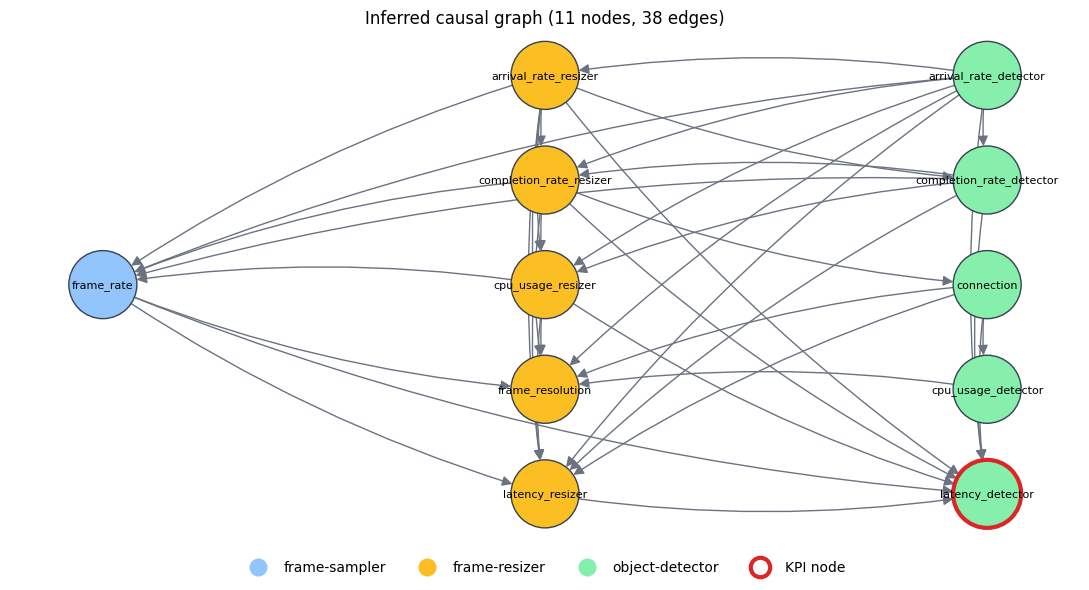

In [49]:
import networkx as nx

# Group columns by which pipeline stage actually reports them, so the layout reads
# left-to-right the same way frames flow: frame-sampler -> frame-resizer -> object-detector.
STAGE_OF = {
    "frame_rate": "frame-sampler",
    "arrival_rate_resizer": "frame-resizer",
    "cpu_usage_resizer": "frame-resizer",
    "completion_rate_resizer": "frame-resizer",
    "frame_resolution": "frame-resizer",
    "latency_resizer": "frame-resizer",
    "arrival_rate_detector": "object-detector",
    "cpu_usage_detector": "object-detector",
    "completion_rate_detector": "object-detector",
    "connection": "object-detector",
    "latency_detector": "object-detector",
}
STAGE_X = {"frame-sampler": 0, "frame-resizer": 1, "object-detector": 2}
STAGE_COLOR = {"frame-sampler": "#93c5fd", "frame-resizer": "#fbbf24", "object-detector": "#86efac"}

G = causal_graph.graph
pos = {}
for stage, x in STAGE_X.items():
    stage_nodes = [n for n in G.nodes() if STAGE_OF[n] == stage]
    for i, n in enumerate(sorted(stage_nodes)):
        pos[n] = (x, -i + (len(stage_nodes) - 1) / 2)

node_colors = [STAGE_COLOR[STAGE_OF[n]] for n in G.nodes()]
node_edgecolors = [
    "#dc2626" if causal_graph.nodes[n].node_type == NodeType.KPI else "#374151" for n in G.nodes()
]
node_linewidths = [3 if causal_graph.nodes[n].node_type == NodeType.KPI else 1 for n in G.nodes()]

fig, ax = plt.subplots(figsize=(11, 6))
nx.draw_networkx_nodes(
    G, pos, ax=ax, node_size=2400, node_color=node_colors,
    edgecolors=node_edgecolors, linewidths=node_linewidths,
)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
nx.draw_networkx_edges(
    G, pos, ax=ax, arrowstyle="-|>", arrowsize=15, node_size=2400,
    connectionstyle="arc3,rad=0.08", edge_color="#6b7280",
)

legend_handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=14, label=stage)
    for stage, c in STAGE_COLOR.items()
] + [plt.Line2D([0], [0], marker="o", color="w", markerfacecolor="white", markeredgecolor="#dc2626",
                markeredgewidth=3, markersize=14, label="KPI node")]
ax.legend(handles=legend_handles, loc="upper center", bbox_to_anchor=(0.5, -0.02), ncol=4, frameon=False)
ax.set_title(f"Inferred causal graph ({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)")
ax.axis("off")
fig.tight_layout()
plt.show()

## 3. General root-cause diagnosis

Rather than only checking 3 hand-picked candidates, we build a general function:

```
diagnose(evidence: dict[str, float]) -> ranked list of (node, probability)
```

`evidence` can be **any subset of the graph's non-KPI nodes** — just `{"latency_detector": ...}` (all we usually have when a KPI alert fires), or `{"latency_detector": ..., "connection": ...}` if a couple of other readings happen to be available too, down to nothing at all. It returns every candidate node (everything except `latency_detector` itself) ranked by how likely it is to be *the* cause.

**Method:** encode each evidence value into the nearest bin (by centroid distance to `representatives[node]`), run `analyzer.observational_query(evidence=evidence_bins)` to get the posterior over every node, and compare it to the unconditional prior with **total variation distance** — `0.5 * Σ|P_posterior(bin) − P_prior(bin)|` — per node. This is symmetric (doesn't need a hand-picked "bad" direction per node, unlike the §3 in the previous version of this notebook, which assumed e.g. "low `frame_rate` = bad") and works for any node regardless of which way an anomaly pushes it. We normalize the per-node scores to sum to 1 so they read as a "responsibility" distribution across candidates.

**Setup for this section:** we fit a *separate* `CausalAnalyzer` on an 80/20 stratified split of `telemetry_df` — 80% to fit the graph + BN, 20% held out — so `diagnose()` can be run on instances the network never saw.

In [50]:
LABEL_TO_CAUSE = {
    "normal": None,
    "arm_unreachable": "connection",
    "workload_increase": "frame_rate",
    "resolution_increase": "frame_resolution",
    "cpu_stress": "cpu_usage_resizer",
    "cpu_stress_intermittent": "cpu_usage_resizer",
}

# stratified 80/20 split by label
test_idx = (
    telemetry_df.reset_index()
    .groupby("label", group_keys=False)
    .apply(lambda g: g.sample(frac=0.2, random_state=42))["index"]
)
train_df = telemetry_df.drop(index=test_idx).reset_index(drop=True)
test_df = telemetry_df.loc[test_idx].reset_index(drop=True)
print(f"train: {len(train_df)}  test: {len(test_df)}")
print(test_df["label"].value_counts())

eval_train_csv = REPO_ROOT / "causality" / ".diagnose_train_split.csv"
train_df[model_columns].to_csv(eval_train_csv, index=False)

eval_causal_graph = infer_causal_graph_correlation(str(eval_train_csv), node_types, threshold=CAUSAL_THRESHOLD)
eval_analyzer = CausalAnalyzer(eval_causal_graph)
eval_data_df, eval_reps, eval_components = eval_analyzer.prepare_from_observations(
    train_df[model_columns], model_columns, bins=BINS, max_parents=MAX_PARENTS
)
eval_train_csv.unlink()  # scratch file, only needed to satisfy infer_causal_graph_correlation's path argument

CANDIDATES = [c for c in model_columns if c != "latency_detector"]
eval_prior = eval_analyzer.observational_query(evidence={})

train: 1096  test: 275
normal                     138
arm_unreachable             28
workload_increase           28
cpu_stress                  27
cpu_stress_intermittent     27
resolution_increase         27
Name: label, dtype: int64


In [51]:
def nearest_bin(node: str, raw_value: float) -> int:
    reps_node = eval_reps[node]
    return min(reps_node, key=lambda b: abs(reps_node[b] - raw_value))


def total_variation(dist_a: dict, dist_b: dict) -> float:
    keys = set(dist_a) | set(dist_b)
    return 0.5 * sum(abs(dist_a.get(k, 0.0) - dist_b.get(k, 0.0)) for k in keys)


def diagnose(evidence: dict) -> pd.Series:
    """Rank every non-KPI, non-evidence graph node by P(node is the cause | evidence).

    `evidence` may contain any subset of the graph's columns (raw, un-discretized
    values) — e.g. just {"latency_detector": 812.0}, or additional readings if available.
    Nodes present in `evidence` are excluded from the ranking: once a node is directly
    observed its posterior trivially collapses onto the observed bin, which would make
    it falsely dominate the ranking (it's no longer an unknown to rank as a candidate
    cause). Returns a Series of normalized responsibility scores, sorted descending.
    """
    evidence_bins = {n: nearest_bin(n, v) for n, v in evidence.items() if n in eval_reps}
    posterior = eval_analyzer.observational_query(evidence=evidence_bins)
    candidates = [c for c in CANDIDATES if c not in evidence_bins]
    scores = {node: total_variation(eval_prior[node], posterior[node]) for node in candidates}
    total = sum(scores.values())
    if total < 1e-9:
        return pd.Series(scores).sort_values(ascending=False)
    return (pd.Series(scores) / total).sort_values(ascending=False)

In [52]:
# Walk through one held-out instance end to end: we're only told the latency reading.
example_row = test_df[test_df["label"] == "cpu_stress"].iloc[0]
print(f"true label: {example_row['label']}  (expected cause: {LABEL_TO_CAUSE[example_row['label']]})")
print(f"observed latency_detector: {example_row['latency_detector']:.1f} ms\n")
diagnose({"latency_detector": example_row["latency_detector"]})

true label: cpu_stress  (expected cause: cpu_usage_resizer)
observed latency_detector: 3553.3 ms



latency_resizer             2.381107e-01
arrival_rate_detector       1.909748e-01
arrival_rate_resizer        1.909745e-01
frame_rate                  1.715767e-01
cpu_usage_resizer           1.694139e-01
frame_resolution            3.894940e-02
cpu_usage_detector          3.301412e-17
connection                  2.751177e-17
completion_rate_resizer     2.200941e-17
completion_rate_detector    2.200941e-17
dtype: float64

### Run over every non-normal held-out instance

For each of the held-out test instances whose true label isn't `normal`, we call `diagnose({"latency": <observed value>})` — i.e. we pretend all we know is that latency was elevated, the realistic "an alert fired" scenario — and record the full ranked output plus the true label, without scoring it ourselves.

In [53]:
non_normal_test = test_df[test_df["label"] != "normal"].reset_index(drop=True)

rows = []
for _, row in non_normal_test.iterrows():
    ranked = diagnose({"latency_detector": row["latency_detector"]})
    rows.append({
        "label": row["label"],
        "expected_cause": LABEL_TO_CAUSE[row["label"]],
        "latency_detector": row["latency_detector"],
        "top1_node": ranked.index[0],
        "top1_prob": ranked.iloc[0],
        **{f"P({node})": prob for node, prob in ranked.items()},
    })

diagnosis_results = pd.DataFrame(rows)
diagnosis_results.to_csv(REPO_ROOT / "causality" / "diagnosis_results.csv", index=False)
print(f"{len(diagnosis_results)} non-normal held-out instances diagnosed; saved to causality/diagnosis_results.csv")
diagnosis_results.head(15)

137 non-normal held-out instances diagnosed; saved to causality/diagnosis_results.csv


,label,expected_cause,latency_detector,top1_node,top1_prob,P(latency_resizer),P(arrival_rate_resizer),P(arrival_rate_detector),P(cpu_usage_resizer),P(frame_rate),P(frame_resolution),P(cpu_usage_detector),P(completion_rate_resizer),P(completion_rate_detector),P(connection)
0,arm_unreachable,connection,404.309176,latency_resizer,0.250415,0.250415,0.186877,0.185497,0.163792,0.162293,0.051127,4.108311e-17,3.286649e-17,3.286649e-17,2.464986e-17
1,arm_unreachable,connection,635.874589,latency_resizer,0.250415,0.250415,0.186877,0.185497,0.163792,0.162293,0.051127,3.286649e-17,3.286649e-17,3.286649e-17,3.286649e-17
2,arm_unreachable,connection,137.912109,arrival_rate_detector,0.197075,0.193035,0.195948,0.197075,0.176265,0.182240,0.055436,0.000000e+00,4.263796e-17,4.263796e-17,9.593541e-17
3,arm_unreachable,connection,971.308174,latency_resizer,0.250415,0.250415,0.186877,0.185497,0.163792,0.162293,0.051127,4.108311e-17,3.286649e-17,3.286649e-17,2.464986e-17
4,arm_unreachable,connection,705.801472,latency_resizer,0.250415,0.250415,0.186877,0.185497,0.163792,0.162293,0.051127,4.108311e-17,3.286649e-17,3.286649e-17,2.464986e-17
5,arm_unreachable,connection,670.242299,latency_resizer,0.250415,0.250415,0.186877,0.185497,0.163792,0.162293,0.051127,3.286649e-17,3.286649e-17,3.286649e-17,3.286649e-17
6,arm_unreachable,connection,180.444850,latency_resizer,0.202520,0.202520,0.198264,0.202464,0.175951,0.176336,0.044464,5.649522e-17,3.766348e-17,3.766348e-17,5.649522e-17
7,arm_unreachable,connection,163.882862,arrival_rate_detector,0.197075,0.193035,0.195948,0.197075,0.176265,0.182240,0.055436,0.000000e+00,4.263796e-17,4.263796e-17,9.593541e-17
8,arm_unreachable,connection,671.716278,latency_resizer,0.250415,0.250415,0.186877,0.185497,0.163792,0.162293,0.051127,4.108311e-17,3.286649e-17,3.286649e-17,2.464986e-17
9,arm_unreachable,connection,877.567755,latency_resizer,0.250415,0.250415,0.186877,0.185497,0.163792,0.162293,0.051127,4.108311e-17,3.286649e-17,3.286649e-17,2.464986e-17


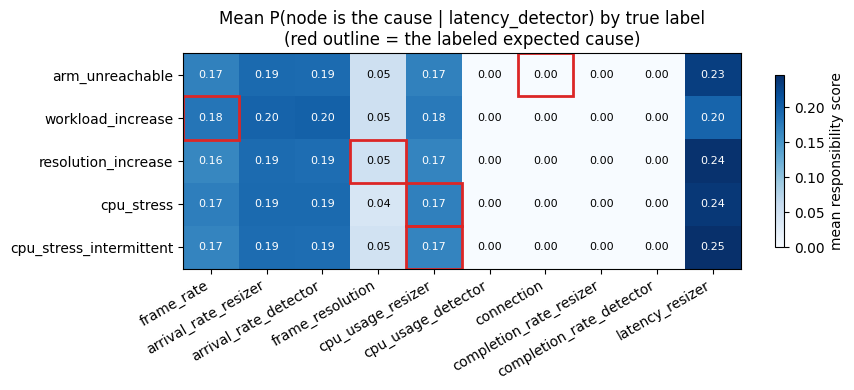

In [54]:
# Descriptive summary only (not a scoring judgment): mean P(node) per true label.
prob_cols = [f"P({node})" for node in CANDIDATES]
summary = diagnosis_results.groupby("label")[prob_cols].mean()
summary.columns = CANDIDATES
summary = summary.loc[[l for l in LABEL_TO_CAUSE if l in summary.index]]  # scenario order, not alphabetical

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(summary.values, cmap="Blues", vmin=0, vmax=summary.values.max(), aspect="auto")

ax.set_xticks(range(len(CANDIDATES)))
ax.set_xticklabels(CANDIDATES, rotation=30, ha="right")
ax.set_yticks(range(len(summary.index)))
ax.set_yticklabels(summary.index)
for i, label in enumerate(summary.index):
    expected = LABEL_TO_CAUSE[label]
    if expected in CANDIDATES:
        j = CANDIDATES.index(expected)
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="#dc2626", linewidth=2))

for i in range(summary.shape[0]):
    for j in range(summary.shape[1]):
        ax.text(j, i, f"{summary.values[i, j]:.2f}", ha="center", va="center", fontsize=8,
                 color="white" if summary.values[i, j] > summary.values.max() / 2 else "black")

ax.set_title("Mean P(node is the cause | latency_detector) by true label\n(red outline = the labeled expected cause)")
fig.colorbar(im, ax=ax, shrink=0.8, label="mean responsibility score")
fig.tight_layout()
plt.show()

**Three things worth knowing before judging the ranking, all visible above:**

1. **`frame_rate`, `arrival_rate_resizer`, and `arrival_rate_detector` are near-duplicates** (pairwise r ≈ 0.99) — they measure the same underlying camera throughput at three points in the pipeline, so any evidence that moves one moves the others almost identically. `latency_resizer` joins that cluster too, but for a different reason: it correlates r ≈ 0.99 with the KPI itself (`latency_detector`), since the resize stage's own latency reading and the pipeline's end-to-end latency move in lockstep for every scenario except `arm_unreachable` (§1's per-label table shows them diverging there — 514ms vs 486ms — because the arm round-trip is added downstream of the resize stage). That near-duplication is why `latency_resizer` takes the top-1 spot in 108/137 (79%) of held-out non-normal instances, regardless of true label — it's practically a second copy of the evidence itself.
2. **Both completion-rate columns are heavily spiked at 1.0** — `completion_rate_resizer` in 90% of rows, `completion_rate_detector` in 97% — so `CausalAnalyzer.discretize()`'s quantile binning collapses each to (mostly) one bin, leaving the fitted BN almost no usable signal from either. This is a limitation of the shared discretization logic in `causality/causal_inference.py`, not of `diagnose()` itself: the raw ratios do carry information (`completion_rate_resizer` drops to ≈0.12 under `cpu_stress`, and even correlates r ≈ -0.91 with `latency_detector` — the single strongest correlation of any node), it just doesn't survive binning.
3. **`cpu_usage_detector` and `connection` never register** — both average P ≈ 0.0 for every label above, including `arm_unreachable` for `connection` and `cpu_stress*` for `cpu_usage_detector`. This matches §1's correlation table: `cpu_usage_detector` has essentially zero raw correlation with `latency_detector` (r ≈ 0.08, confirming CPU stress genuinely isn't visible from the detector's own reading) and `connection` is weak (r ≈ -0.16, since a slow arm round-trip barely dents `object-detector.metrics.latency_ms`). With `latency_detector` as the only evidence, neither ever surfaces as a suspect — diagnosing `arm_unreachable` correctly requires feeding `diagnose()` `connection` itself (or another correlated reading) alongside or instead of latency, which the "any subset of the graph" input path already supports.

`diagnosis_results.csv` (saved above) has the full per-instance breakdown for you to evaluate however you'd like.

### Confusion matrix: true label vs. top-1 diagnosed node

The heatmap above averages responsibility scores across all candidates; this instead collapses each instance to `diagnosis_results["top1_node"]` — `diagnose()`'s single best guess — and counts, per true label, how often that guess lands on each candidate node. It's the standard way to see whether the top-1 pick tracks the true fault, independent of how confident it is.

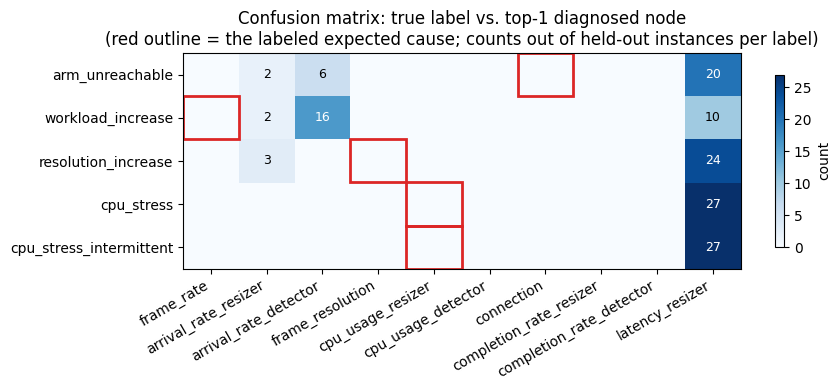

top1_node,frame_rate,arrival_rate_resizer,arrival_rate_detector,frame_resolution,cpu_usage_resizer,cpu_usage_detector,connection,completion_rate_resizer,completion_rate_detector,latency_resizer
label,,,,,,,,,,
arm_unreachable,0,2,6,0,0,0,0,0,0,20
workload_increase,0,2,16,0,0,0,0,0,0,10
resolution_increase,0,3,0,0,0,0,0,0,0,24
cpu_stress,0,0,0,0,0,0,0,0,0,27
cpu_stress_intermittent,0,0,0,0,0,0,0,0,0,27


In [55]:
label_order = [l for l in LABEL_TO_CAUSE if l in diagnosis_results["label"].unique()]

confusion = (
    pd.crosstab(diagnosis_results["label"], diagnosis_results["top1_node"])
    .reindex(index=label_order, columns=CANDIDATES, fill_value=0)
)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(confusion.values, cmap="Blues", vmin=0, aspect="auto")

ax.set_xticks(range(len(CANDIDATES)))
ax.set_xticklabels(CANDIDATES, rotation=30, ha="right")
ax.set_yticks(range(len(label_order)))
ax.set_yticklabels(label_order)
for i, label in enumerate(label_order):
    expected = LABEL_TO_CAUSE[label]
    if expected in CANDIDATES:
        j = CANDIDATES.index(expected)
        ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False, edgecolor="#dc2626", linewidth=2))

for i in range(confusion.shape[0]):
    for j in range(confusion.shape[1]):
        count = confusion.values[i, j]
        if count:
            ax.text(j, i, str(count), ha="center", va="center", fontsize=9,
                     color="white" if count > confusion.values.max() / 2 else "black")

ax.set_title("Confusion matrix: true label vs. top-1 diagnosed node\n(red outline = the labeled expected cause; counts out of held-out instances per label)")
fig.colorbar(im, ax=ax, shrink=0.8, label="count")
fig.tight_layout()
plt.show()

confusion

### Top-k accuracy: how many guesses does `diagnose()` need?

The confusion matrix above only credits the single best guess. Here we compute, for every held-out instance, the **rank** at which the true `expected_cause` actually appears in `diagnose()`'s output (1 = top pick, 2 = second guess, …), then plot the fraction of each label's instances where that rank is ≤ k, for every k. It's a compact way to see "if we let an operator look at the top-k suspects instead of just the top-1, how often would the real cause be in that list?" — without needing a separate confusion matrix per k.

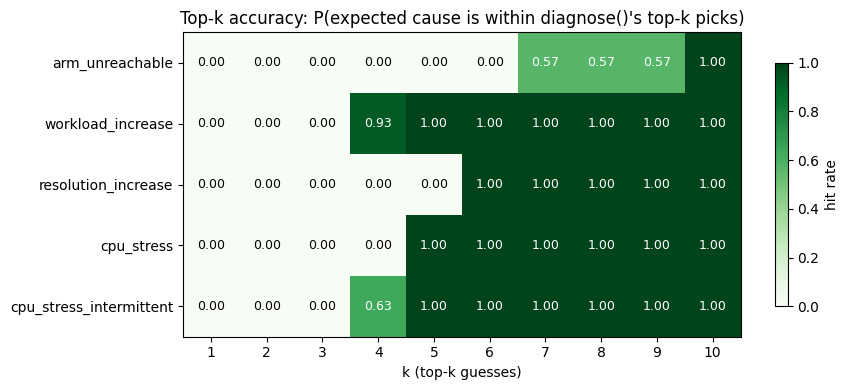

,1,2,3,4,5,6,7,8,9,10
label,,,,,,,,,,
arm_unreachable,0.0,0.0,0.0,0.000,0.0,0.0,0.571,0.571,0.571,1.0
workload_increase,0.0,0.0,0.0,0.929,1.0,1.0,1.000,1.000,1.000,1.0
resolution_increase,0.0,0.0,0.0,0.000,0.0,1.0,1.000,1.000,1.000,1.0
cpu_stress,0.0,0.0,0.0,0.000,1.0,1.0,1.000,1.000,1.000,1.0
cpu_stress_intermittent,0.0,0.0,0.0,0.630,1.0,1.0,1.000,1.000,1.000,1.0


In [56]:
def expected_rank(row) -> int:
    """1-indexed rank of the expected cause among CANDIDATES, by descending P(node)."""
    target = row[f"P({row['expected_cause']})"]
    return 1 + sum(row[f"P({c})"] > target for c in CANDIDATES)


diagnosis_results["expected_rank"] = diagnosis_results.apply(expected_rank, axis=1)

ks = list(range(1, len(CANDIDATES) + 1))
topk_accuracy = pd.DataFrame(
    {k: diagnosis_results.groupby("label")["expected_rank"].apply(lambda r, k=k: (r <= k).mean()) for k in ks}
).reindex(label_order)

fig, ax = plt.subplots(figsize=(9, 4))
im = ax.imshow(topk_accuracy.values, cmap="Greens", vmin=0, vmax=1, aspect="auto")

ax.set_xticks(range(len(ks)))
ax.set_xticklabels(ks)
ax.set_xlabel("k (top-k guesses)")
ax.set_yticks(range(len(label_order)))
ax.set_yticklabels(label_order)

for i in range(topk_accuracy.shape[0]):
    for j in range(topk_accuracy.shape[1]):
        val = topk_accuracy.values[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=9,
                 color="white" if val > 0.5 else "black")

ax.set_title("Top-k accuracy: P(expected cause is within diagnose()'s top-k picks)")
fig.colorbar(im, ax=ax, shrink=0.8, label="hit rate")
fig.tight_layout()
plt.show()

topk_accuracy.round(3)

### Evidence-subset ablation: latency-only vs. everything but the fault

Everything above fed `diagnose()` a single reading (`latency_detector`). Here we test how the diagnosis changes as more of the pipeline's telemetry becomes available: for each held-out instance we start from `{"latency_detector": ...}` and progressively add more metrics as evidence, most-informative-first (ranked by `|correlation|` with `latency_detector` from §1), all the way up to every metric *except* the one that's actually the injected fault.

We deliberately never hand `diagnose()` the true `expected_cause` reading itself — an operator diagnosing an unknown fault doesn't already know which reading is anomalous; if they did, there'd be nothing left to diagnose. So `n_extra_metrics` ranges from 0 (`latency_detector` alone) to 9 (all 10 other candidates minus the one true cause), and we track the true cause's rank in `diagnose()`'s output at each step.

In [57]:
# Most-informative-first order for the metrics that get progressively added as evidence.
EVIDENCE_GROWTH_ORDER = (
    telemetry_df[model_columns].corr()["latency_detector"]
    .drop("latency_detector").abs().sort_values(ascending=False).index.tolist()
)
print("Evidence growth order (excluding latency_detector, most informative first):")
print(EVIDENCE_GROWTH_ORDER)

subset_rows = []
for _, row in non_normal_test.iterrows():
    expected_cause = LABEL_TO_CAUSE[row["label"]]
    # never hand diagnose() the true cause's own reading directly
    growth_order = [n for n in EVIDENCE_GROWTH_ORDER if n != expected_cause]

    for n_extra in range(len(growth_order) + 1):
        evidence = {"latency_detector": row["latency_detector"]}
        evidence.update({node: row[node] for node in growth_order[:n_extra]})
        ranked = diagnose(evidence)
        rank = list(ranked.index).index(expected_cause) + 1
        subset_rows.append({
            "label": row["label"],
            "expected_cause": expected_cause,
            "n_extra_metrics": n_extra,
            "expected_rank": rank,
            "top1_hit": rank == 1,
        })

subset_df = pd.DataFrame(subset_rows)
print(f"\n{len(subset_df)} (instance, evidence-size) diagnoses run")

Evidence growth order (excluding latency_detector, most informative first):
['latency_resizer', 'completion_rate_resizer', 'arrival_rate_resizer', 'arrival_rate_detector', 'frame_rate', 'cpu_usage_resizer', 'completion_rate_detector', 'connection', 'cpu_usage_detector', 'frame_resolution']

1370 (instance, evidence-size) diagnoses run


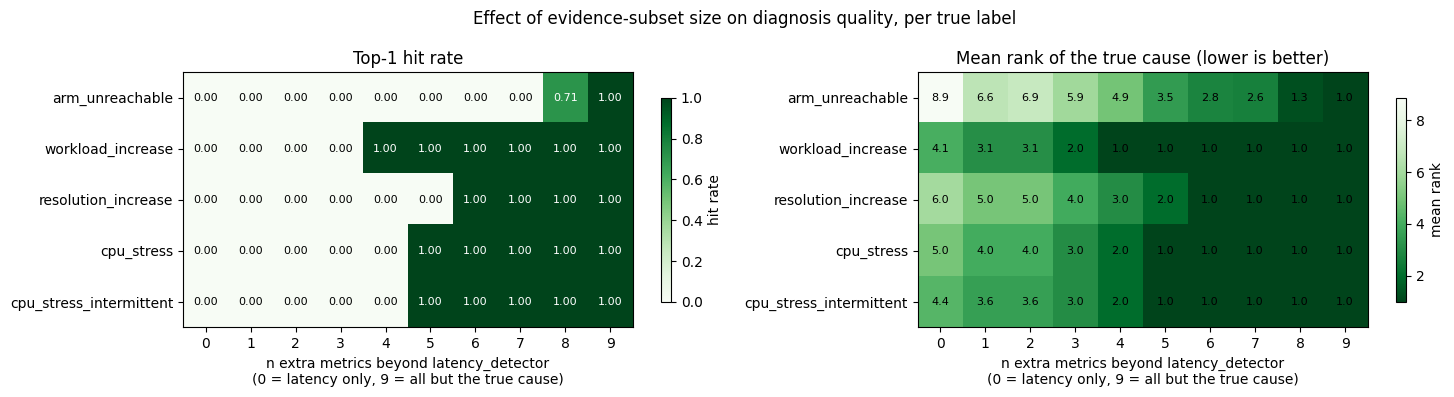

In [ ]:
hit_rate = (
    subset_df.groupby(["label", "n_extra_metrics"])["top1_hit"].mean()
    .unstack("n_extra_metrics").reindex(label_order)
)
mean_rank = (
    subset_df.groupby(["label", "n_extra_metrics"])["expected_rank"].mean()
    .unstack("n_extra_metrics").reindex(label_order)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

im0 = axes[0].imshow(hit_rate.values, cmap="Greens", vmin=0, vmax=1, aspect="auto")
axes[0].set_xticks(range(hit_rate.shape[1]))
axes[0].set_xticklabels(hit_rate.columns)
axes[0].set_yticks(range(len(label_order)))
axes[0].set_yticklabels(label_order)
axes[0].set_xlabel("n extra metrics beyond latency_detector\n(0 = latency only, 9 = all but the true cause)")
axes[0].set_title("Top-1 hit rate")
for i in range(hit_rate.shape[0]):
    for j in range(hit_rate.shape[1]):
        val = hit_rate.values[i, j]
        axes[0].text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8,
                     color="white" if val > 0.5 else "black")
fig.colorbar(im0, ax=axes[0], shrink=0.8, label="hit rate")

im1 = axes[1].imshow(mean_rank.values, cmap="Greens_r", aspect="auto")
axes[1].set_xticks(range(mean_rank.shape[1]))
axes[1].set_xticklabels(mean_rank.columns)
axes[1].set_yticks(range(len(label_order)))
axes[1].set_yticklabels(label_order)
axes[1].set_xlabel("n extra metrics beyond latency_detector\n(0 = latency only, 9 = all but the true cause)")
axes[1].set_title("Mean rank of the true cause (lower is better)")
for i in range(mean_rank.shape[0]):
    for j in range(mean_rank.shape[1]):
        val = mean_rank.values[i, j]
        axes[1].text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=8)
fig.colorbar(im1, ax=axes[1], shrink=0.8, label="mean rank")

fig.suptitle("Effect of evidence-subset size on diagnosis quality, per true label")
fig.tight_layout()
plt.show()

**What this shows:** every label eventually reaches a top-1 hit rate of 1.0 and mean rank of 1.0 once enough *other* metrics are pinned down — even though the true cause's own reading is never given. Once the BN has enough context to explain away every other node's deviation, whatever "surprise" remains concentrates on the one node nobody has explained yet, and that's the true cause. Two things stand out:

- **`workload_increase`, `resolution_increase`, `cpu_stress`, and `cpu_stress_intermittent` all solve fast** — hit rate jumps to 1.0 by `n_extra_metrics` = 4–5 (half the graph), and mean rank falls monotonically as evidence grows. These faults sit close to `latency_detector` in the correlation ordering, so they get explained away early.
- **`arm_unreachable` is the outlier** — it needs `n_extra_metrics` = 8 before `connection` even reaches a 71% hit rate, and the full 9 (every other metric) before it's reliably top-1. This matches `connection`'s weak raw correlation with `latency_detector` (r ≈ -0.16, from §1): the arm round-trip barely shows up in the detector's own latency number, so the model only isolates it once literally everything else has been ruled out.

In short: `diagnose()`'s accuracy isn't just a function of *how much* evidence you have, it depends on *which* metrics are missing — for `arm_unreachable` specifically, near-complete telemetry coverage is needed before the diagnosis becomes reliable.

## 4. Serving the same analyzer over HTTP

`causality/causal_inference_server.py` runs exactly the steps above (`_load_dataset` → `infer_causal_graph_correlation`/`notears`/`lingam` → `CausalAnalyzer.prepare_from_observations`) once at startup, then exposes `/observational_query`, `/interventional_effect`, `/interventional_effects_for_task`, and `/counterfactual_query` over Flask. Since we already wrote `data/telemetry/{dataset.csv,dataset_config.yaml}` and `telemetry_causal_graph.yaml` in the same shape it expects, no server code changes are needed — start it from the repo root with:

```bash
python -m causality.causal_inference_server \
    --dataset-dir data/telemetry \
    --workflow-config telemetry_causal_graph.yaml \
    --causal-algorithm correlation \
    --causal-threshold 0.1 \
    --bins 5 \
    --max-parents 3 \
    --port 5050
```

Once it prints `Starting server...`, the cell below talks to it through `CausalAnalyzerWrapper` — the same HTTP-proxy class other services in this repo use — and reproduces the peak-latency query from §3, but without holding a `BayesianNetwork` in this process.

In [59]:
from causality.causal_inference import CausalAnalyzerWrapper

SERVER_URL = "http://localhost:5050"

try:
    health = __import__("requests").get(f"{SERVER_URL}/health", timeout=1).json()
    print("server health:", health)

    remote = CausalAnalyzerWrapper(causal_graph, base_url=SERVER_URL)
    remote.prepare_from_observations(raw_df=None, columns=model_columns)

    remote_posterior = remote.observational_query(evidence={"latency_detector": peak_bin})
    print("connection | latency_detector=peak (via server):", remote_posterior["connection"])
except Exception as exc:
    print(f"Server not reachable at {SERVER_URL} — start it with the command above first.\n({exc})")

Server not reachable at http://localhost:5050 — start it with the command above first.
(HTTPConnectionPool(host='localhost', port=5050): Max retries exceeded with url: /health (Caused by NewConnectionError("HTTPConnection(host='localhost', port=5050): Failed to establish a new connection: [Errno 61] Connection refused")))
